In [1]:
!pip install transformers torchinfo==1.8.0 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 12.8 MB/s eta 0:00:00


# **Logit Lens**

Hello, dear reader!

This tutorial explores the method for analyzing internal representations known as the "Logit Lens."

**By completing this tutorial, you will:**

* Learn the approach and concept of the Logit Lens;
- Implement the Logit Lens for a Visual Transformer;
- Get acquainted with the analysis of Logit Lens results.

Let's get started!


## **A Bit About the Method**  

The Logit Lens method was introduced on [LessWrong](https://www.lesswrong.com/posts/AcKRB8wDpdaN6v6ru/interpreting-gpt-the-logit-lens) in 2020 using the GPT-2 model as an example.  

The lens itself is quite a complex method to implement—each model requires a unique approach to its construction, based on an analysis of its architecture.  

At the same time, this complexity gives the method certain advantages!  

- The method is **model-specific** (i.e., it focuses on a single model), allowing for an in-depth study of the behavior of hidden representations across different models.  

How do they relate to each other? Perhaps you will discover something fascinating, and I hope this tutorial will inspire you!  


## **Theory**  

Before we begin, let's go over the foundations of the method. It is based on logits and hidden states—it's important to understand what these are.  

#### **1. Logits**  

Let's recall the binary classification task using a logistic regression model. In addition to the [probabilistic formulation](https://towardsdatascience.com/introduction-to-probabilistic-classification-a-machine-learning-perspective-b4776b469453/), we can look at it this way:  

**Goal:** Predict the probability of a specific class (in the range $[0,1]$).  
**Problem:** A linear model is not constrained within this range.  

To solve this, we use a **logit transformation**—first, we train the model on a value range of $(−∞,∞)$, then transform the outputs into probabilities using the sigmoid function.  

In this case, we say that we predict **logits**—values given by:

$$z = \ln\left(\frac{p}{1 - p}\right)$$

where \( p \) is the desired probability. We then transform these logits using the sigmoid function:

$$p(y=1 | x) = \frac{1}{1+e^{-z}}$$

A similar idea applies to multi-class classification, where the **softmax function** is used instead. Formally, if $z_i$ are the logits for all tokens $i$, we compute the probability vector $p$, where the probability at index $i$ is given by:

$$p(y_i \mid x) = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

Thus, in general, logits can be defined as follows:  

**Logits** are the input values to the softmax/sigmoid function before they are transformed into probabilities. For each token, they represent raw "pre-" probabilities (logits) used to determine the next word in a sequence.  

This definition slightly differs from the [statistical formulation](https://en.wikipedia.org/wiki/Logit), but in this context, it is necessary for understanding the task.


##### **2. Hidden State**  

The concept of a hidden state is related to the hidden layers of a model. In general, the term "hidden" layer means the following:  

A **hidden layer** of a model $Net(x)$ is any architectural layer with an output, except for the first (input) and last (output) layers.  

From this definition, if $Net(x)$ is a deep neural network with an arbitrary architecture containing layers from 1 to $N$, then the **hidden state of the model** is the representation $h^{(l)}$—the output after the $l$-th layer, where $l \neq N $and $l \neq 1$.  

# **Logit Lens**  

Now that we have the definitions, we can explore the concept and construction of the Logit Lens.  

Any large model can be viewed as a sequence of hidden states $ h^{(l)}(x_{l-1})$, where $x_{l-1}$ is the output of the previous layer.  

Writing this in detail, for a model $Net(x)$, we get:  

$$input \to Net(input) \to output$$

Given $N$ layers, we can abstractly represent it as:  

$$input \to h^{(0)} \to h^{(1)} \to h^{(2)} \to ... \to h^{(k)} \to .... \to h^{(N-1)} \to output$$

Based on this, if the transformations $ h^{(l)}$ are consistent with each other (i.e., have the same size), we can investigate how the model forms predictions at different layers by projecting the hidden layer representation onto the output value vector.  

In this case, the **Logit Lens of a hidden layer** $h^{(l)} $ is defined as the projection:

$$h^{(l)} = W_{\text{out}} h_l$$

where $W_{\text{out}}$ represents the output layer weights.  

This method is not applicable to all models. The key requirement for its applicability is the **architectural consistency** described above.  

**Great! We've covered the theory—let's move on to practice!**  








In [2]:
# Importing libraries
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

from tqdm import tqdm
from PIL import Image
import seaborn as sns
import os
from torchinfo import summary

from transformers import AutoImageProcessor, ViTForImageClassification

The next steps involve downloading the dataset that we will use for practice.  


In [3]:
# Downloading the dataset for practice — 1
!wget https://github.com/SadSabrina/XAI-open_materials/raw/refs/heads/main/yolo_nas_cam_tutorial/coco_test/coco_test.zip

--2025-03-13 16:55:45--  https://github.com/SadSabrina/XAI-open_materials/raw/refs/heads/main/yolo_nas_cam_tutorial/coco_test/coco_test.zip
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/SadSabrina/XAI-open_materials/refs/heads/main/yolo_nas_cam_tutorial/coco_test/coco_test.zip [following]
--2025-03-13 16:55:45--  https://raw.githubusercontent.com/SadSabrina/XAI-open_materials/refs/heads/main/yolo_nas_cam_tutorial/coco_test/coco_test.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17277668 (16M) [application/zip]
Saving to: ‘coco_test.zip’

coco_test.zip       100%[===================>]  16

In [4]:
# Downloading the dataset for practice — 2
!file /content/coco_test.zip

/content/coco_test.zip: Zip archive data, at least v1.0 to extract, compression method=store


In [5]:
# Downloading the dataset for practice — 3
!unzip /content/coco_test.zip

Archive:  /content/coco_test.zip
   creating: yolo_nas_cam_tutorial/coco_test/
  inflating: yolo_nas_cam_tutorial/coco_test/.DS_Store  
  inflating: yolo_nas_cam_tutorial/coco_test/sheep.jpg  
  inflating: yolo_nas_cam_tutorial/coco_test/bird.jpg  
  inflating: yolo_nas_cam_tutorial/coco_test/cow.jpg  
  inflating: yolo_nas_cam_tutorial/coco_test/cat.jpg  
  inflating: yolo_nas_cam_tutorial/coco_test/giraffe.jpg  
  inflating: yolo_nas_cam_tutorial/coco_test/horses.jpg  
  inflating: yolo_nas_cam_tutorial/coco_test/bear.jpg  


 So, we have loaded 8 images for our work. Let's take a look at them.


In [6]:
image_files = os.listdir('/content/yolo_nas_cam_tutorial/coco_test/')[1:]
len(image_files)
image_files

['bear.jpg',
 'giraffe.jpg',
 'sheep.jpg',
 'cat.jpg',
 'horses.jpg',
 'bird.jpg',
 'cow.jpg']

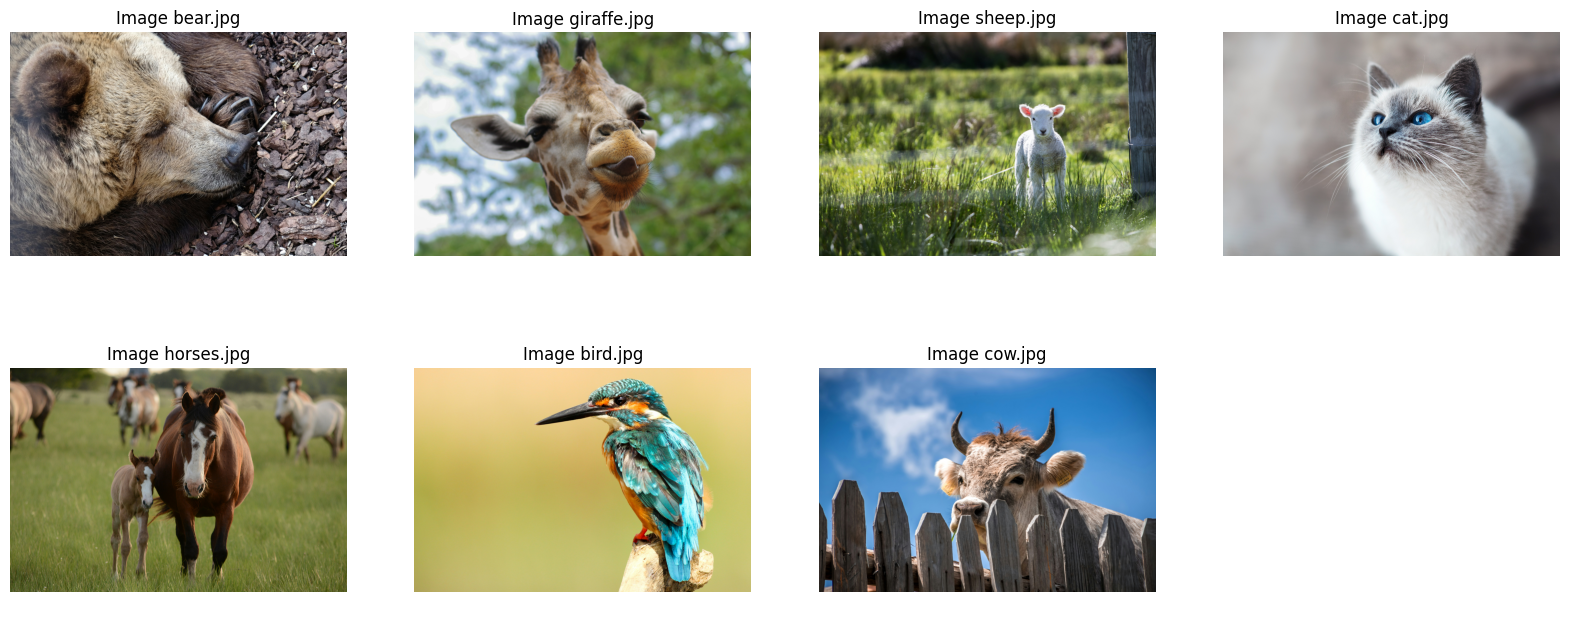

In [149]:
ROOT_PATH = '/content/yolo_nas_cam_tutorial/coco_test/'

images_list = [Image.open('/content/yolo_nas_cam_tutorial/coco_test/'+i) for i in image_files]

# Display the files
num_columns = 4
num_rows = 2

fig, axes = plt.subplots(num_rows, num_columns, figsize=(20, 8))

for i, ax in enumerate(axes.flatten()):
    ax.axis('off')
    if i < len(images_list):
        ax.imshow(images_list[i])
        ax.set_title(f"Image {image_files[i]}")

plt.show()

The images are ready. Now let's import the model.

In [150]:
# import the image processor
image_processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")

# import the model
model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224")
model.eval()

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTSdpaAttention(
            (attention): ViTSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_fe

## **Model Analysis**  

To understand where the logits will come from, let's take a look at the model's architecture and the information about the outputs of the hidden layers. For this, we will need an input example and the `summary` function from the `torchinfo` library.  

In [151]:
# x0 example
input0 = image_processor(images_list[0], return_tensors="pt",)

In [152]:
summary(model, input_data=input0['pixel_values'], depth=6)

Layer (type:depth-idx)                                       Output Shape              Param #
ViTForImageClassification                                    [1, 1000]                 --
├─ViTModel: 1-1                                              [1, 197, 768]             --
│    └─ViTEmbeddings: 2-1                                    [1, 197, 768]             152,064
│    │    └─ViTPatchEmbeddings: 3-1                          [1, 196, 768]             --
│    │    │    └─Conv2d: 4-1                                 [1, 768, 14, 14]          590,592
│    │    └─Dropout: 3-2                                     [1, 197, 768]             --
│    └─ViTEncoder: 2-2                                       [1, 197, 768]             --
│    │    └─ModuleList: 3-3                                  --                        --
│    │    │    └─ViTLayer: 4-2                               [1, 197, 768]             --
│    │    │    │    └─LayerNorm: 5-1                         [1, 197, 768]           

Notice that both the encoder and the embedding layer refine features of the same size. However, the embeddings (ViTEmbeddings) and the encoder (ViTEncoder) perform different functions:

1. **Embeddings (ViTEmbeddings)**  
   Responsible for transforming the input image into a sequence of tokens (feature vectors);
2. **Encoder (ViTEncoder)**  
   Responsible for processing the sequence of embeddings, extracting complex spatial and contextual dependencies from them.  

Based on this, we will consider the output layers of the encoder (ViTEncoder) for projecting into the Logit Lens.  


## **Extracting Hidden Representations**

In the `transformers` library, hidden states can be returned using a simple attribute during inference.

The syntax is as follows:



```
model = Net()
outputs = model(**inputs, output_hidden_states=True)

```

Now, let's extract them from the model.  



In [153]:
outputs = model(**input0, output_hidden_states=True)

# Extracting the predicted class.
predicted_class_idx = torch.sigmoid(outputs.logits).argmax(-1).item()
labels = model.config.id2label  # indexes and lanels dict

print(f"Predicted: {labels[predicted_class_idx]}")
print(f'Hidden states count: {len(outputs.hidden_states)}')

Predicted: brown bear, bruin, Ursus arctos
Количество извлеченных скрытых состояний: 13


In [154]:
outputs.logits.shape

torch.Size([1, 1000])

So, we have obtained the correct prediction — the model sees a [bear](https://salient-imagenet.cs.umd.edu/explore/class_294/feature_140.html) and 13 hidden states.

* The first one ('outputs.hidden_states[0]') is the output from the embedding part `model.vit.embeddings`.
* States 2-13 are outputs from parts of the encoder — all before the application of the final layer component `model.vit` — `layernorm`.

We will discard the first one. We are interested in states from 1 to 13.  

In [155]:
hidden_states = outputs.hidden_states[1:]

Let's see how to extract the projections. On one hand, we could create a child model with fewer encoder layers. This approach is described in the article [here](https://medium.com/@adjileyeb/unlocking-visual-insights-applying-the-logit-lens-to-image-data-with-vision-transformers-b99cb70dd704) (which also includes code).

However, we will take a different approach and consider the states of a single model.

Now, for extracting the projections. To do this, we need to pass each hidden state through the classification weights. These are located in the model's `classifier` module. Let's extract it.  


In [157]:
classification_layer = model.classifier

Now we are ready to build the lenses. However, if we look at the dimensions of the hidden states, each hidden state has a shape of `[1, 197, 768]`. After applying a linear layer, we get a vector of shape `[1, 197]` — one class for each patch.

**What is this related to?**

In the ViT model, the CLS token is used for classification. It corresponds to the 0th patch. We can either take this token or use the median/mean across all patches.

Let's implement both approaches and check the results.  

In [158]:
cls_hidden = hidden_states[-1][:, 0, :] # extracting CLS token
median_hidden = torch.median(hidden_states[-1], dim=1)[0] # extracting median

# extracting classification result (logits)
classification_result_cls = classification_layer(cls_hidden)
classification_result_median = classification_layer(median_hidden)

# extracting classification result (probas)
predicted_class_cls = torch.softmax(classification_result_cls, dim=-1)
predicted_class_median = torch.softmax(classification_result_cls, dim=-1)

print(f'Predicted class on CLS token: {predicted_class_cls.argmax()}')
print(f'Predicted class on median: {predicted_class_median.argmax()}')

Predicted class on CLS token: 294
Predicted class on median: 294


For the last hidden state, the results are the same. At this point, we have everything we need to iterate through all the hidden states — from understanding the theory to grasping the practical nuances! Let's write a function for this.  

In [159]:
def get_hidden_state_result(hidden_state, true_class_idx, mode='CLS'):

  if mode == 'CLS':
    hidden_state = hidden_state[:, 0, :] # Extract the hidden state corresponding to the [CLS] token (first token in the sequence)
  if mode == 'median':  # Take the median across the patches (dim=1 refers to the second dimension which is the patches)
    hidden_state = torch.median(hidden_state, dim=1)[0]

  classification_layer_result = classification_layer(hidden_state)  # Apply classification layer
  predicted_class_probas = torch.softmax(classification_layer_result, dim=-1) # Apply softmax to get class probabilities

# Get the predicted class index and probability
  predicted_class_idx = predicted_class_probas.argmax().item()
  predicted_class_proba = predicted_class_probas.max().item()

# Get the rank of the true class
 #Sort the predicted probabilities in descending order and find the rank of the true class
# by looking for the true class index in the sorted tensor.

  _, indexes_sorted = torch.sort(predicted_class_probas, descending = True)
  final_label_rank = torch.where(indexes_sorted == true_class_idx)[-1].item()

  return predicted_class_proba, predicted_class_idx, final_label_rank

In [160]:
true_class_idx = 294

bear_image_probas = []
bear_image_predictions = []
bear_image_true_ranks = []

for hidden_state in hidden_states:
  predicted_class_proba, predicted_class_idx, final_label_rank = get_hidden_state_result(hidden_state, true_class_idx, mode='CLS')

  bear_image_probas.append(predicted_class_proba)
  bear_image_predictions.append(predicted_class_idx)
  bear_image_true_ranks.append(final_label_rank)

In [161]:
bear_table = [bear_image_probas, bear_image_predictions, bear_image_true_ranks]

Let's take a look at the results!  

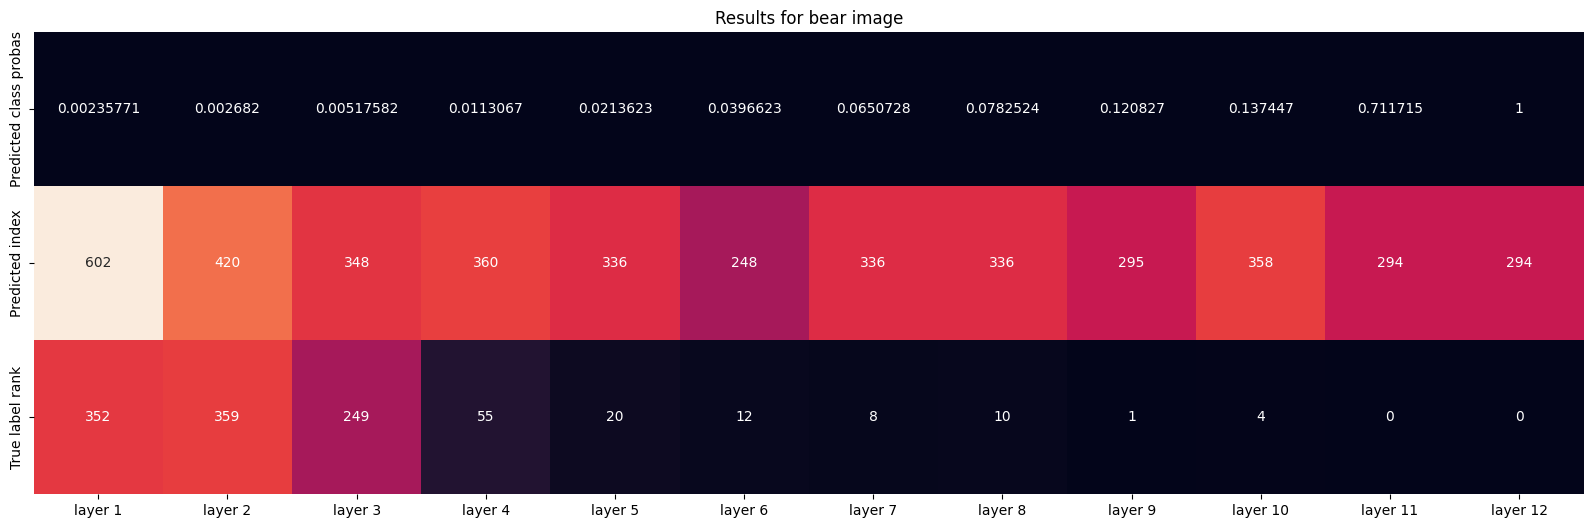

In [162]:
fig, ax = plt.subplots(figsize=(20, 6))

sns.heatmap(bear_table, annot=True, ax=ax, cbar=False, fmt='g')

ax.set_xticklabels([f'layer {i+1}' for i in range(12)]);
ax.set_yticklabels(['Predicted class probas', 'Predicted index', 'True label rank']);
ax.set_title('Results for bear image');

### **Building Logit Lenses on Other Images**

In [173]:
images_results = {}
predicted_labels = []

for image_name, image_file in zip(image_files, images_list):
  # for each image

  input = image_processor(image_file, return_tensors="pt") # run the model
  outputs = model(**input, output_hidden_states=True)

  # Extracting the predicted class.
  predicted_class_ = torch.sigmoid(outputs.logits).argmax(-1).item()
  labels = model.config.id2label
  predicted_label = labels[predicted_class_]

# Extracting hidden states
  hidden_states = outputs.hidden_states[1:]

  image_probas = []
  image_predictions = []
  image_true_ranks = []

# Extracting Logit Lenses on hidden states
  for hidden_state in hidden_states:
    predicted_class_proba, predicted_class_idx, final_label_rank = get_hidden_state_result(hidden_state, predicted_class_, mode='CLS')

    image_probas.append(predicted_class_proba)
    image_predictions.append(predicted_class_idx)
    image_true_ranks.append(final_label_rank)

  images_results[image_name] = [image_probas, image_predictions, image_true_ranks]
  predicted_labels.append(predicted_label)

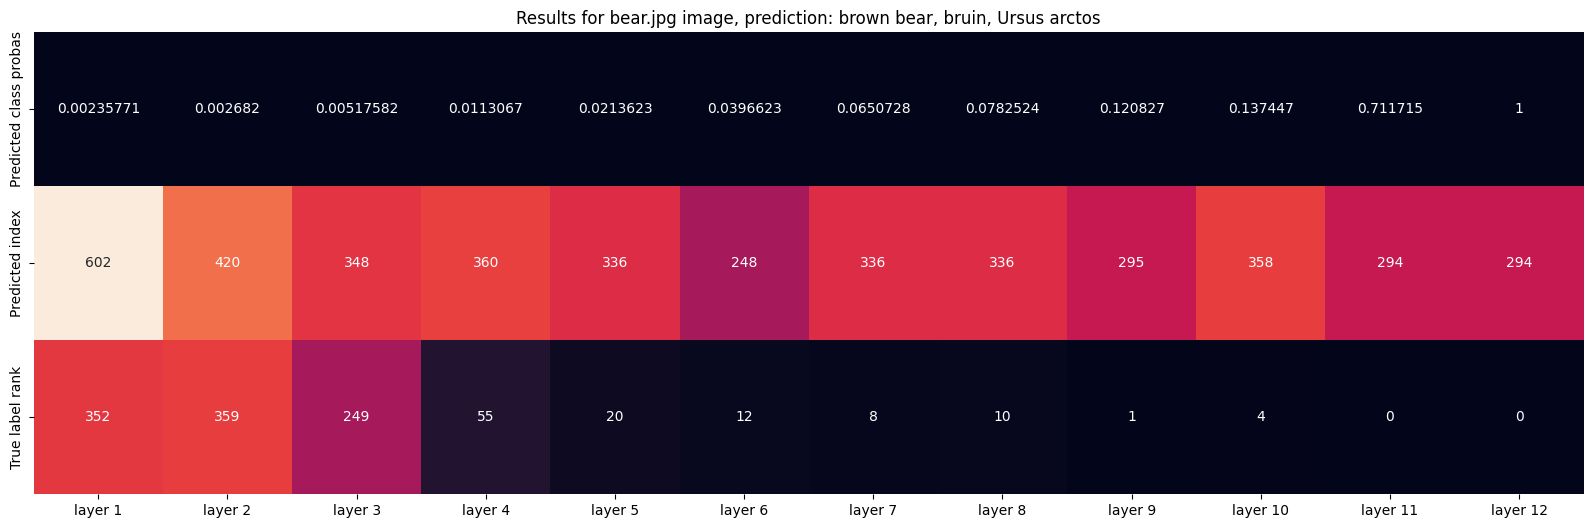

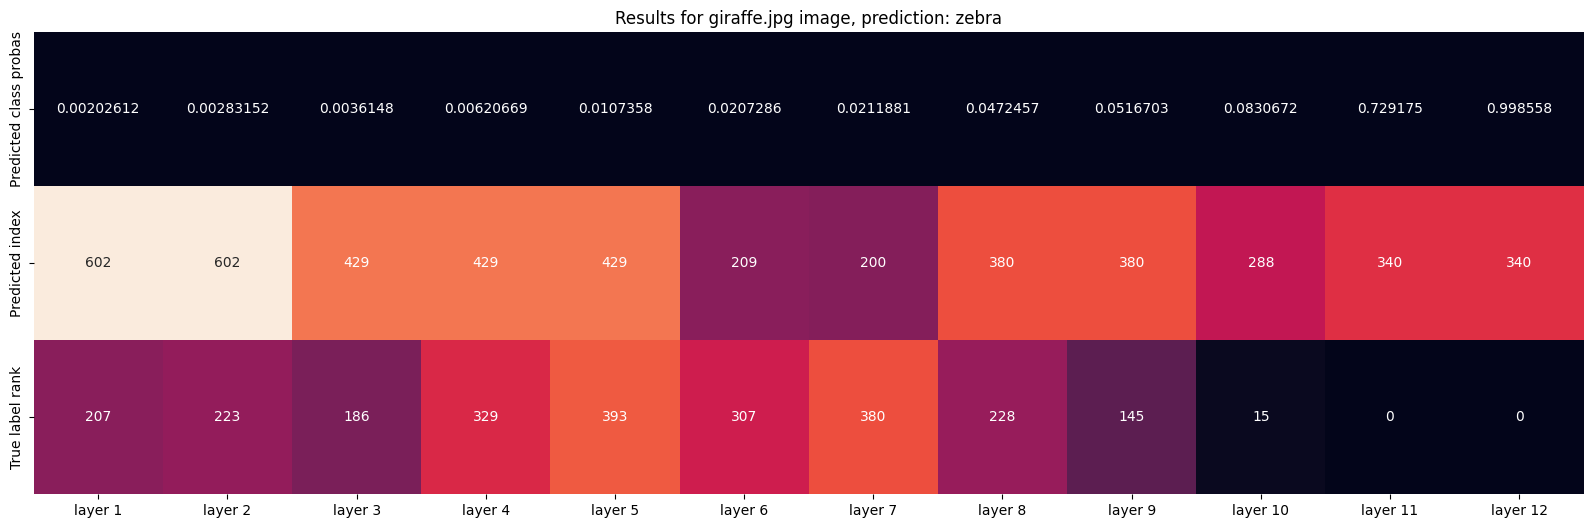

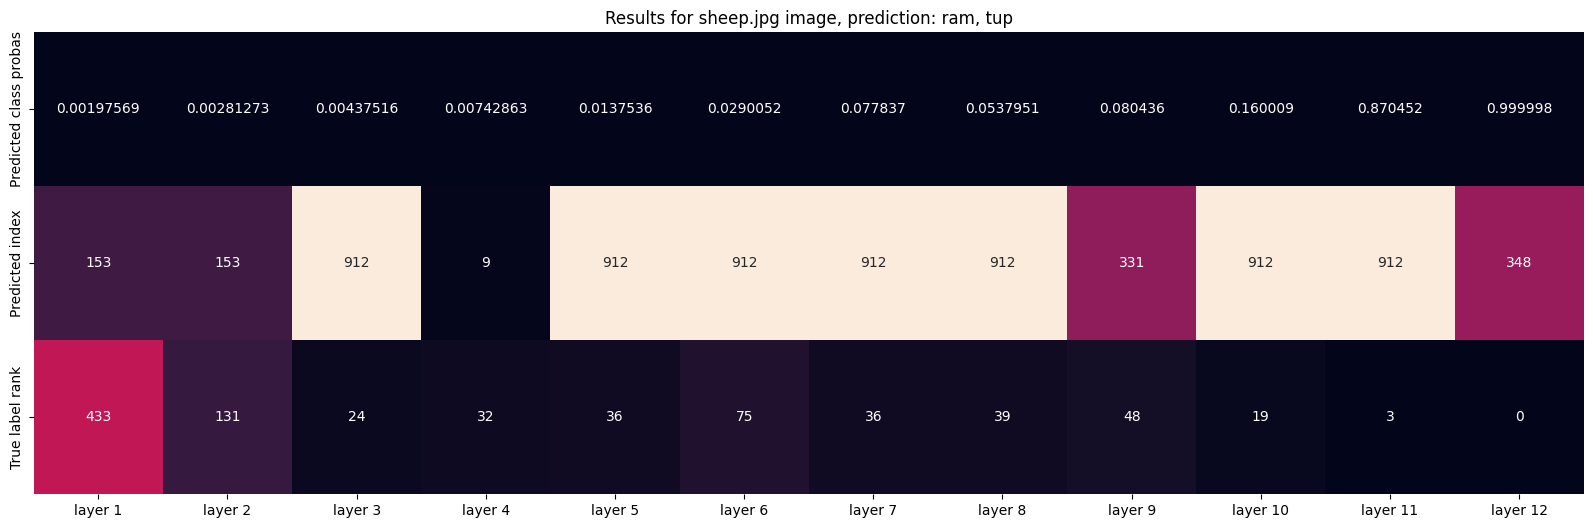

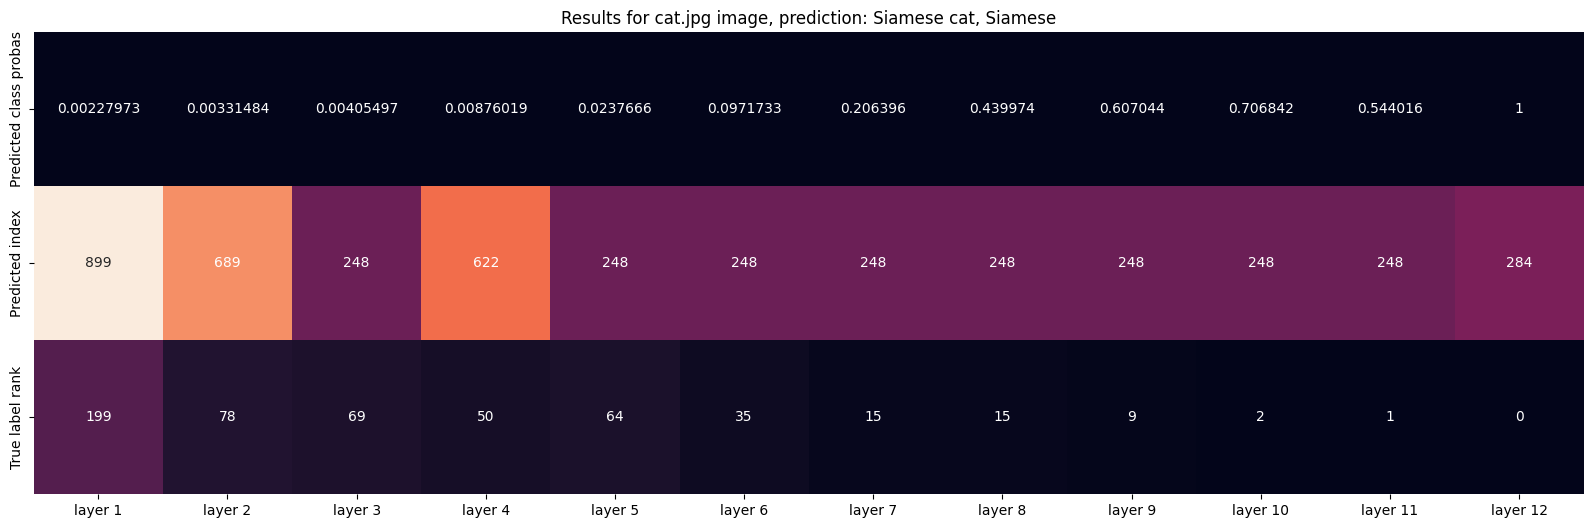

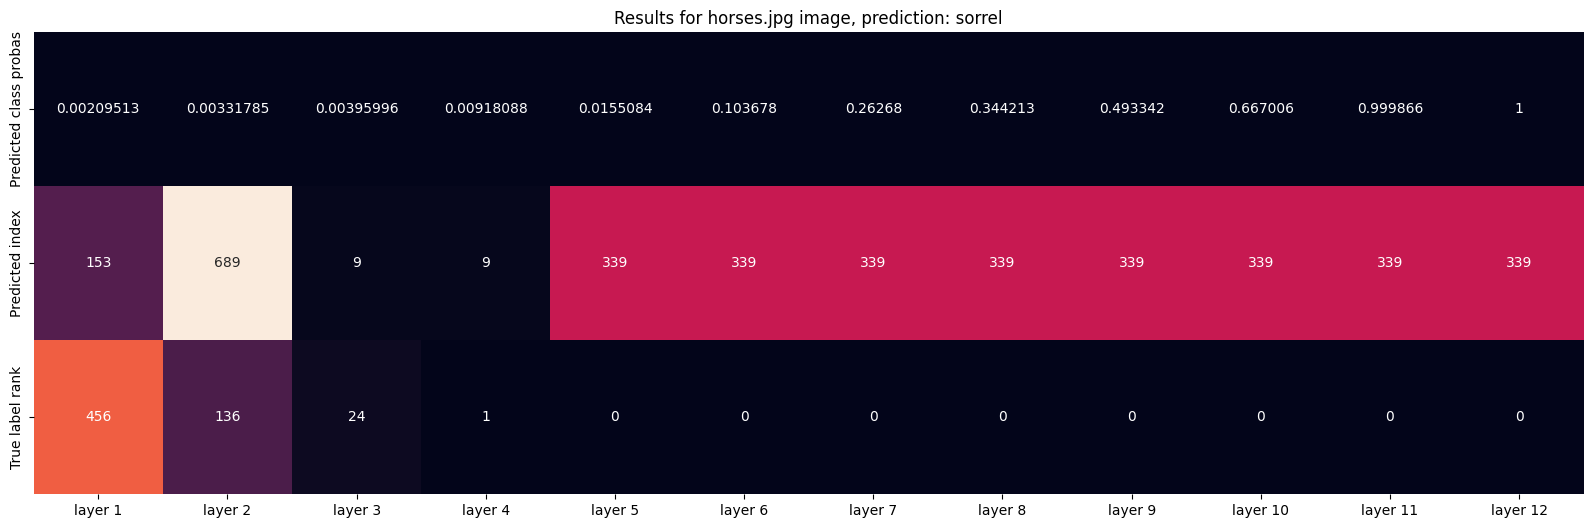

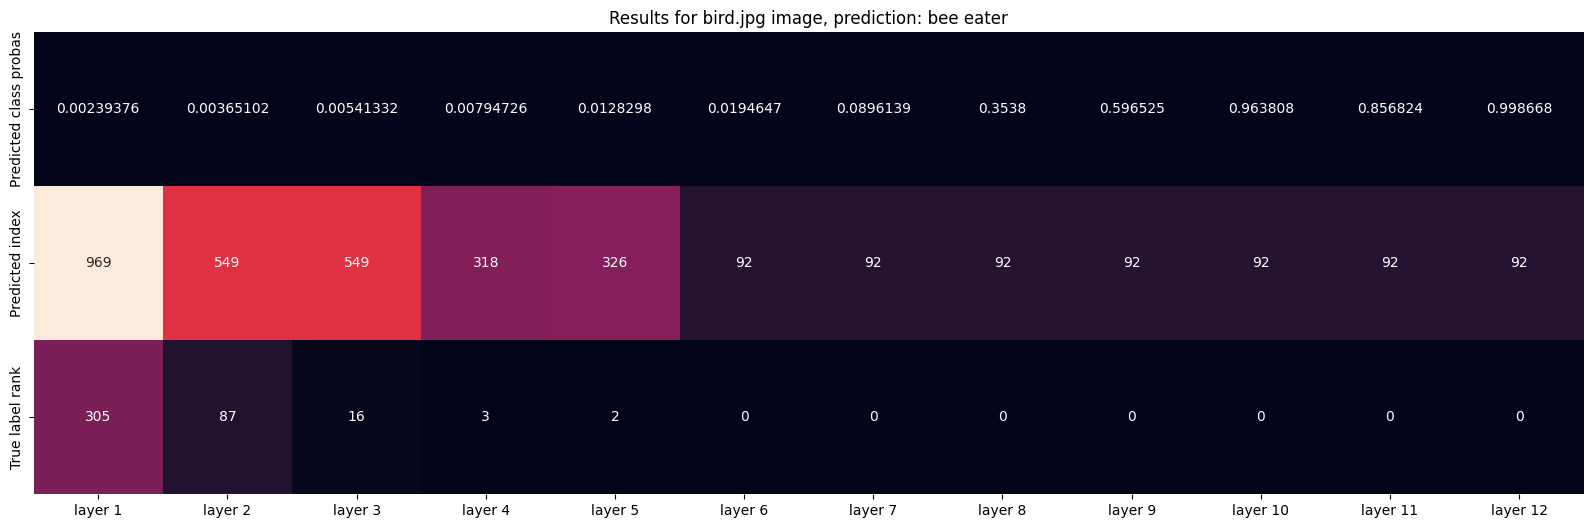

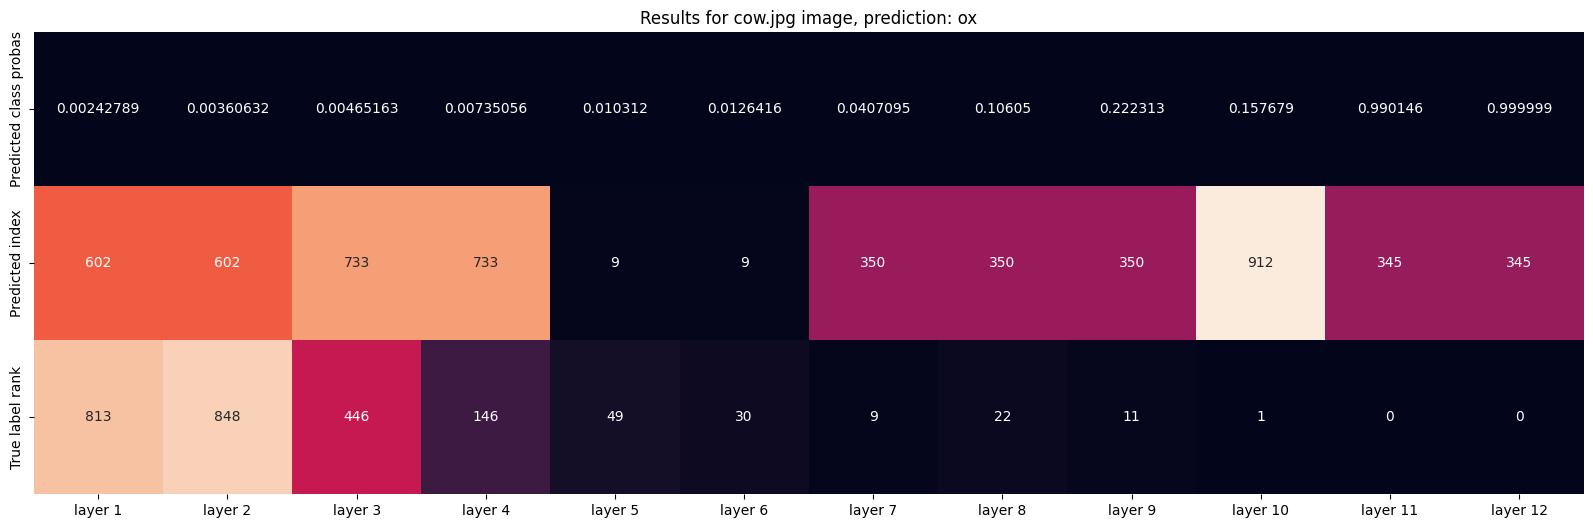

In [175]:
predicted_list_indexes = 0

for image_name, image_table in images_results.items():

  fig, ax = plt.subplots(figsize=(20, 6))
  sns.heatmap(image_table, annot=True, ax=ax, cbar=False, fmt='g')

  ax.set_xticklabels([f'layer {i+1}' for i in range(12)]);
  ax.set_yticklabels(['Predicted class probas', 'Predicted index', 'True label rank']);
  ax.set_title(f'Results for {image_name} image, prediction: {predicted_labels[predicted_list_indexes]}');
  predicted_list_indexes += 1

## **Conclusions:**

* In some examples, the prediction may stabilize at early layers (layers 4-5 for horses, birds).
* The true class (according to the prediction) tends to be in the top-3 at the last layers, but this is not true for all images (counterexample — sheep).
* Confidence (expressed by probability) in the prediction sharply increases at the last two layers (the third-from-last can be either stable in confidence or not, for example, cow with 0.15 and bird with 0.9).


Thank you for your time spent on this tutorial! I hope it has revealed the beauty of the method and inspired you in some way 😌

I really enjoy creating open materials, so join my [Telegram channel (rus)](https://t.me/jdata_blog) to stay updated with new releases!

I also invite you to take my [course (rus)](https://stepik.org/a/198640) on explainable AI methods and, of course, I'd be happy to connect with you on [LinkedIn](https://www.linkedin.com/in/sabrina-sadiekh-35181a286/).

Wishing you successful and incredibly beautiful projects!  
Your Data-Author!  